In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/telco_churn_cleaned.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

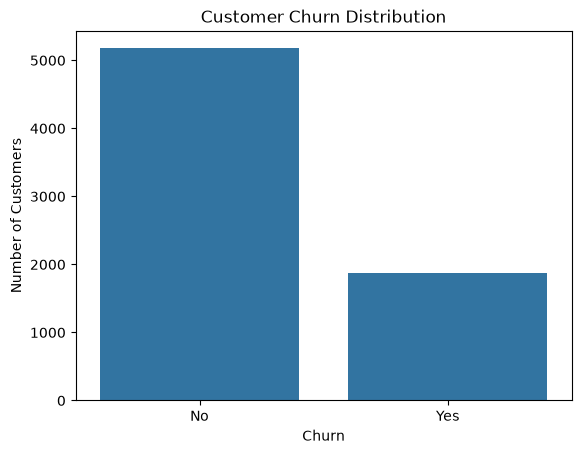

In [7]:
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

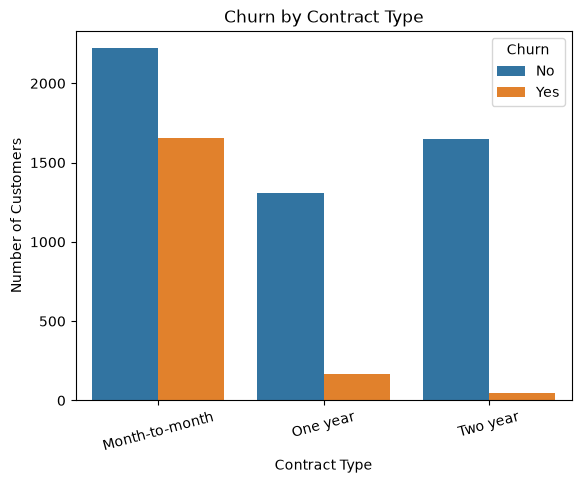

In [8]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

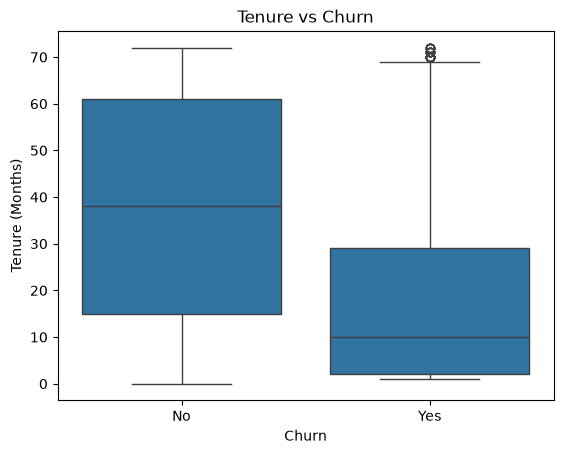

In [9]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

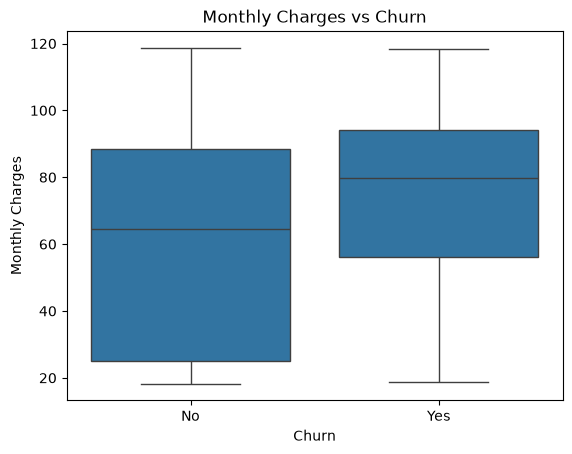

In [10]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

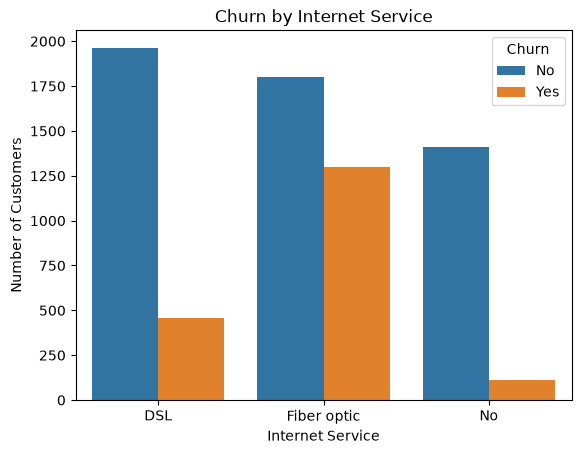

In [11]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

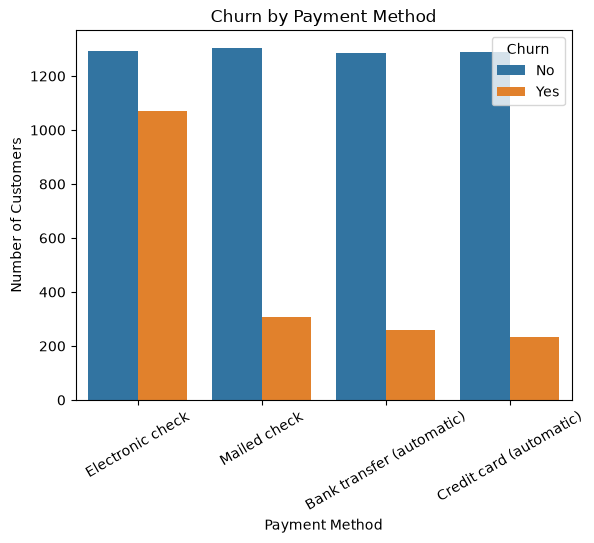

In [12]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

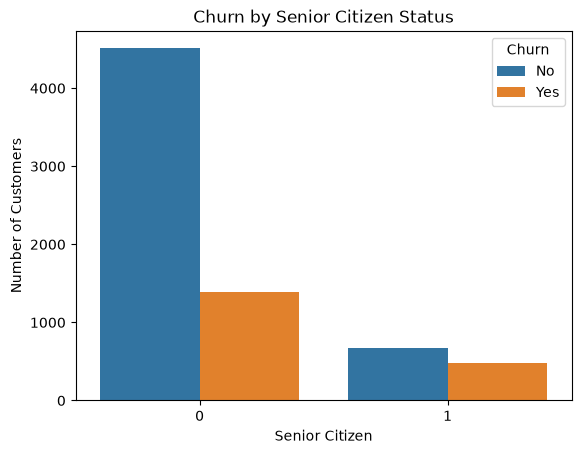

In [13]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')
plt.show()

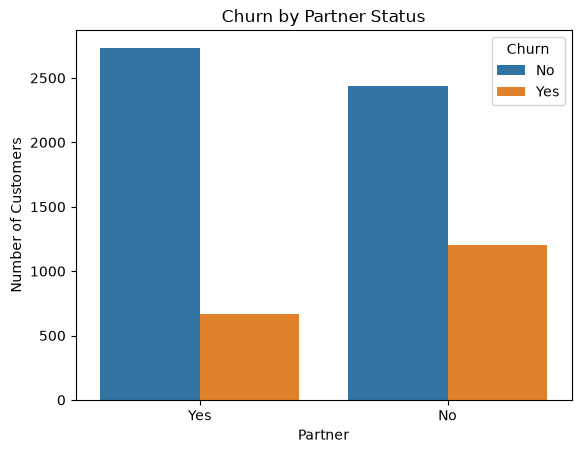

In [14]:
sns.countplot(data=df, x='Partner', hue='Churn')
plt.title('Churn by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Number of Customers')
plt.show()

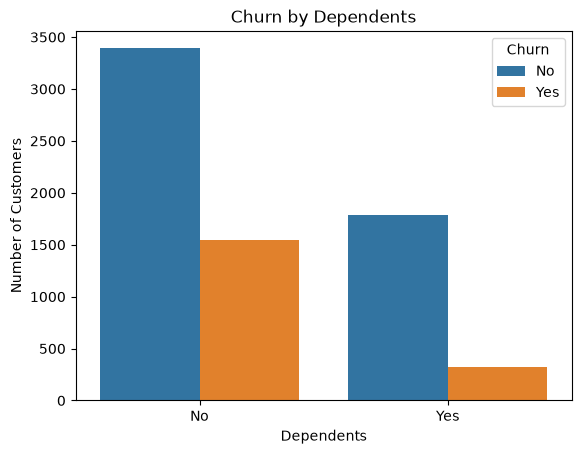

In [15]:
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.title('Churn by Dependents')
plt.xlabel('Dependents')
plt.ylabel('Number of Customers')
plt.show()

In [16]:
numeric_df = df.select_dtypes(include='number')

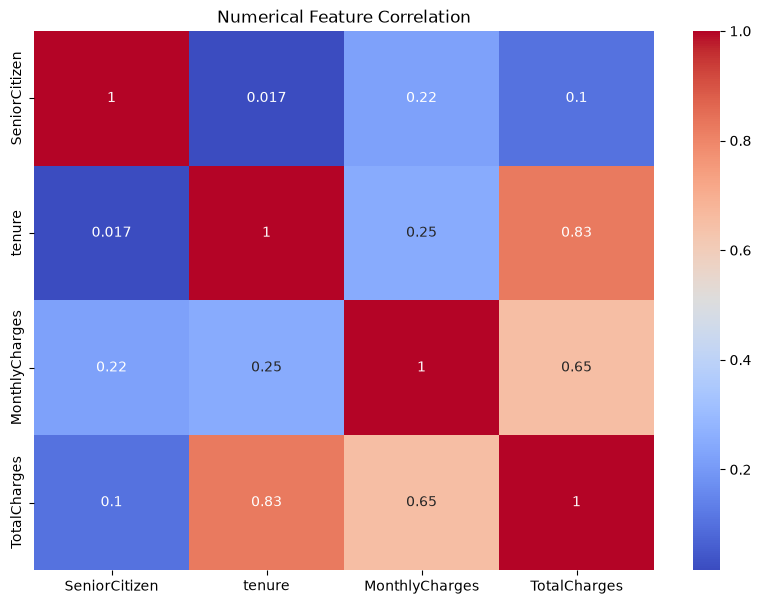

In [17]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Numerical Feature Correlation')
plt.show()

In [18]:
def tenure_group(tenure):
    if tenure <= 12:
        return 'New (0-1yr)'
    elif tenure <= 48:
        return 'Mid (1-4yr)'
    else:
        return 'Loyal (4yr+)'

In [19]:
df['tenure_group'] = df['tenure'].apply(tenure_group)

In [20]:
df['tenure_group'].value_counts()

tenure_group
Mid (1-4yr)     2618
Loyal (4yr+)    2239
New (0-1yr)     2186
Name: count, dtype: int64

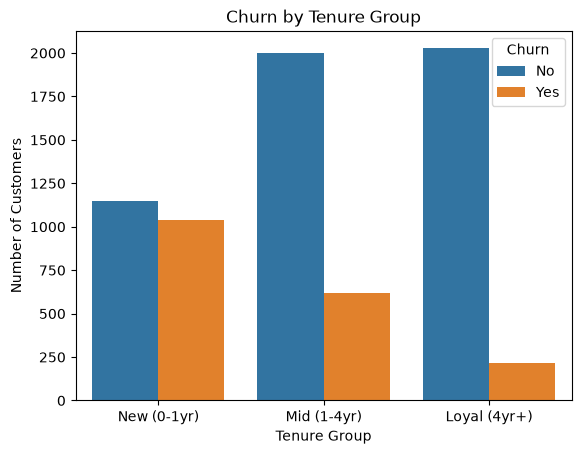

In [21]:
sns.countplot(
    data=df,
    x='tenure_group',
    hue='Churn'
)

plt.title('Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.show()

In [22]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [23]:
tenure_churn = pd.crosstab(
    df['tenure_group'],
    df['Churn'],
    normalize='index'
) * 100

tenure_churn

Churn,No,Yes
tenure_group,,
Loyal (4yr+),90.486824,9.513176
Mid (1-4yr),76.355997,23.644003
New (0-1yr),52.561757,47.438243


In [24]:
df.to_csv(
    "../data/telco_churn_eda.csv",
    index=False
)